In [1]:
# Обновление окружения:
using Pkg
Pkg.update
# Установка пакетов:
using Pkg
for p in ["CSV", "DataFrames", "RDatasets", "FileIO"]
Pkg.add(p)
end
using CSV, DataFrames, DelimitedFiles

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\eldar\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\eldar\.julia\environments\v1.12\Manifest.toml`
Precompiling packages...
   5092.9 ms  ? StochasticDiffEq
   7094.4 ms  ? DifferentialEquations
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\eldar\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\eldar\.julia\environments\v1.12\Manifest.toml`
Precompiling packages...
   4893.1 ms  ? StochasticDiffEq
   6777.3 ms  ? DifferentialEquations
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\eldar\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\eldar\.julia\environments\v1.12\Manifest.toml`
Precompiling packages...
   4934.5 ms  ? StochasticDiffEq
   6805.7 ms

In [9]:
# Считывание данных и их запись в структуру:
P = CSV.File("C:programminglanguages.csv") |> DataFrame

Row,year,language
,Int64,String31
1,1951,Regional Assembly Language
2,1952,Autocode
3,1954,IPL
4,1955,FLOW-MATIC
5,1957,FORTRAN
6,1957,COMTRAN
7,1958,LISP
8,1958,ALGOL 58
9,1959,FACT


In [4]:
# Функция определения по названию языка программирования года его создания:
function language_created_year(P,language::String)
loc = findfirst(P[:,2].==language)
return P[loc,1]
end

language_created_year (generic function with 1 method)

In [5]:
# Пример вызова функции и определение даты создания языка Python:
language_created_year(P,"Python")

1991

In [6]:
# Пример вызова функции и определение даты создания языка Julia:
language_created_year(P,"Julia")

2012

In [7]:
language_created_year(P,"julia")

LoadError: MethodError: no method matching getindex(::DataFrame, ::Nothing, ::Int64)
The function `getindex` exists, but no method is defined for this combination of argument types.

[0mClosest candidates are:
[0m  getindex(::DataFrame, [91m::typeof(!)[39m, ::Union{Signed, Unsigned})
[0m[90m   @[39m [36mDataFrames[39m [90mC:\Users\eldar\.julia\packages\DataFrames\b4w9K\src\dataframe\[39m[90m[4mdataframe.jl:548[24m[39m
[0m  getindex(::DataFrame, [91m::Colon[39m, ::Union{AbstractString, Signed, Symbol, Unsigned})
[0m[90m   @[39m [36mDataFrames[39m [90mC:\Users\eldar\.julia\packages\DataFrames\b4w9K\src\dataframe\[39m[90m[4mdataframe.jl:542[24m[39m
[0m  getindex(::DataFrame, [91m::AbstractVector[39m, ::Union{AbstractString, Signed, Symbol, Unsigned})
[0m[90m   @[39m [36mDataFrames[39m [90mC:\Users\eldar\.julia\packages\DataFrames\b4w9K\src\dataframe\[39m[90m[4mdataframe.jl:530[24m[39m
[0m  ...


In [8]:
# Функция определения по названию языка программирования
# года его создания (без учёта регистра):
function language_created_year_v2(P,language::String)
loc = findfirst(lowercase.(P[:,2]).==lowercase.(language))
return P[loc,1]
end
# Пример вызова функции и определение даты создания языка julia:
language_created_year_v2(P,"julia")

2012

In [10]:
# Построчное считывание данных с указанием разделителя:
Tx = readdlm("programminglanguages.csv", ',')

74×2 Matrix{Any}:
     "year"  "language"
 1951        "Regional Assembly Language"
 1952        "Autocode"
 1954        "IPL"
 1955        "FLOW-MATIC"
 1957        "FORTRAN"
 1957        "COMTRAN"
 1958        "LISP"
 1958        "ALGOL 58"
 1959        "FACT"
 1959        "COBOL"
 1959        "RPG"
 1962        "APL"
    ⋮        
 2003        "Scala"
 2005        "F#"
 2006        "PowerShell"
 2007        "Clojure"
 2009        "Go"
 2010        "Rust"
 2011        "Dart"
 2011        "Kotlin"
 2011        "Red"
 2011        "Elixir"
 2012        "Julia"
 2014        "Swift"

In [11]:
CSV.write("programming_languages_data2.csv", P)

"programming_languages_data2.csv"

In [13]:
# Пример записи данных в текстовый файл с разделителем ',':
writedlm("programming_languages_data.txt", Tx, ',')
# Пример записи данных в текстовый файл с разделителем '-':
writedlm("programming_languages_data2.txt", Tx, '-')

In [14]:
# Построчное считывание данных с указанием разделителя:
P_new_delim = readdlm("programming_languages_data2.txt", '-')

74×2 Matrix{Any}:
     "year"  "language"
 1951        "Regional Assembly Language"
 1952        "Autocode"
 1954        "IPL"
 1955        "FLOW-MATIC"
 1957        "FORTRAN"
 1957        "COMTRAN"
 1958        "LISP"
 1958        "ALGOL 58"
 1959        "FACT"
 1959        "COBOL"
 1959        "RPG"
 1962        "APL"
    ⋮        
 2003        "Scala"
 2005        "F#"
 2006        "PowerShell"
 2007        "Clojure"
 2009        "Go"
 2010        "Rust"
 2011        "Dart"
 2011        "Kotlin"
 2011        "Red"
 2011        "Elixir"
 2012        "Julia"
 2014        "Swift"

In [15]:
# Инициализация словаря:
dict2 = Dict()

Dict{Any, Any}()

In [17]:
dict = Dict{Integer,Vector{String}}()

Dict{Integer, Vector{String}}()

In [18]:
# Заполнение словаря данными:
for i = 1:size(P,1)
year,lang = P[i,:]
if year in keys(dict)
dict[year] = push!(dict[year],lang)
else
dict[year] = [lang]
end
end

In [19]:
# Пример определения в словаре языков программирования, созданных в 2003 году:
dict[2003]

2-element Vector{String}:
 "Groovy"
 "Scala"

In [20]:
# Подгружаем пакет DataFrames:
using DataFrames
# Задаём переменную со структурой DataFrame:
df = DataFrame(year = P[:,1], language = P[:,2])
# Вывод всех значения столбца year:
df[!,:year]
# Получение статистических сведений о фрейме:
describe(df)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Union…,Any,Union…,Any,Int64,DataType
1,year,1982.99,1951,1986.0,2014,0,Int64
2,language,,ALGOL 58,,dBase III,0,String31


In [21]:
# Подгружаем пакет RDatasets:
using RDatasets
# Задаём структуру данных в виде набора данных:
iris = dataset("datasets", "iris")

Row,SepalLength,SepalWidth,PetalLength,PetalWidth,Species
,Float64,Float64,Float64,Float64,Cat…
1,5.1,3.5,1.4,0.2,setosa
2,4.9,3.0,1.4,0.2,setosa
3,4.7,3.2,1.3,0.2,setosa
4,4.6,3.1,1.5,0.2,setosa
5,5.0,3.6,1.4,0.2,setosa
6,5.4,3.9,1.7,0.4,setosa
7,4.6,3.4,1.4,0.3,setosa
8,5.0,3.4,1.5,0.2,setosa
9,4.4,2.9,1.4,0.2,setosa


In [22]:
# Определения типа переменной:
typeof(iris)

DataFrame

In [23]:
describe(iris)

Row,variable,mean,min,median,max,nmissing,eltype
,Symbol,Union…,Any,Union…,Any,Int64,DataType
1,SepalLength,5.84333,4.3,5.8,7.9,0,Float64
2,SepalWidth,3.05733,2.0,3.0,4.4,0,Float64
3,PetalLength,3.758,1.0,4.35,6.9,0,Float64
4,PetalWidth,1.19933,0.1,1.3,2.5,0,Float64
5,Species,,setosa,,virginica,0,"CategoricalValue{String, UInt8}"


In [24]:
# Отсутствующий тип:
a = missing
typeof(a)

Missing

In [25]:
# Определение перечня продуктов:
foods = ["apple", "cucumber", "tomato", "banana"]
# Определение калорий:
calories = [missing,47,22,105]
# Определение типа переменной:
typeof(calories)


Vector{Union{Missing, Int64}} (alias for Array{Union{Missing, Int64}, 1})

In [26]:
# Подключаем пакет Statistics:
using Statistics
# Определение среднего значения:
mean(calories)

missing

In [27]:
# Определение среднего значения без значений с отсутствующим типом:
mean(skipmissing(calories))

58.0

In [29]:
# Задание сведений о ценах:
prices = [0.85,1.6,0.8,0.6]
# Формирование данных о калориях:
dataframe_calories = DataFrame(item=foods,calories=calories)
# Формирование данных о ценах:
dataframe_prices = DataFrame(item=foods,price=prices)
# Объединение данных о калориях и ценах:
DF = innerjoin(dataframe_calories,dataframe_prices,on=:item)

Row,item,calories,price
,String,Int64?,Float64
1,apple,missing,0.85
2,cucumber,47,1.6
3,tomato,22,0.8
4,banana,105,0.6


In [30]:
using FileIO

In [33]:
import Pkg
Pkg.add("ImageIO")
# Загрузка изображения:
X1 = load("julialogo.png")

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\eldar\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\eldar\.julia\environments\v1.12\Manifest.toml`


512×512 Matrix{ColorTypes.RGBA{FixedPointNumbers.N0f8}}:
 RGBA(0.0, 0.0, 0.0, 0.0)  …  RGBA(0.0, 0.0, 0.0, 0.0)
 RGBA(0.0, 0.0, 0.0, 0.0)     RGBA(0.0, 0.0, 0.0, 0.0)
 RGBA(0.0, 0.0, 0.0, 0.0)     RGBA(0.0, 0.0, 0.0, 0.0)
 RGBA(0.0, 0.0, 0.0, 0.0)     RGBA(0.0, 0.0, 0.0, 0.0)
 RGBA(0.0, 0.0, 0.0, 0.0)     RGBA(0.0, 0.0, 0.0, 0.0)
 RGBA(0.0, 0.0, 0.0, 0.0)  …  RGBA(0.0, 0.0, 0.0, 0.0)
 RGBA(0.0, 0.0, 0.0, 0.0)     RGBA(0.0, 0.0, 0.0, 0.0)
 RGBA(0.0, 0.0, 0.0, 0.0)     RGBA(0.0, 0.0, 0.0, 0.0)
 RGBA(0.0, 0.0, 0.0, 0.0)     RGBA(0.0, 0.0, 0.0, 0.0)
 RGBA(0.0, 0.0, 0.0, 0.0)     RGBA(0.0, 0.0, 0.0, 0.0)
 RGBA(0.0, 0.0, 0.0, 0.0)  …  RGBA(0.0, 0.0, 0.0, 0.0)
 RGBA(0.0, 0.0, 0.0, 0.0)     RGBA(0.0, 0.0, 0.0, 0.0)
 RGBA(0.0, 0.0, 0.0, 0.0)     RGBA(0.0, 0.0, 0.0, 0.0)
 ⋮                         ⋱  
 RGBA(0.0, 0.0, 0.0, 0.0)  …  RGBA(0.0, 0.0, 0.0, 0.0)
 RGBA(0.0, 0.0, 0.0, 0.0)     RGBA(0.0, 0.0, 0.0, 0.0)
 RGBA(0.0, 0.0, 0.0, 0.0)     RGBA(0.0, 0.0, 0.0, 0.0)
 RGBA(0.0, 0.0, 0.0, 0.0)     RG

In [34]:
@show typeof(X1);

typeof(X1) = Matrix{ColorTypes.RGBA{FixedPointNumbers.N0f8}}


In [35]:
@show size(X1);

size(X1) = (512, 512)


In [9]:
# Загрузка пакетов:
import Pkg
Pkg.add("DataFrames")
Pkg.add("Statistics")
Pkg.add("DataFramesMeta")
using DataFrames
using CSV
import Pkg
Pkg.add("Plots")

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\eldar\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\eldar\.julia\environments\v1.12\Manifest.toml`
Precompiling packages...
   5126.9 ms  ? StochasticDiffEq
   7097.3 ms  ? DifferentialEquations
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\eldar\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\eldar\.julia\environments\v1.12\Manifest.toml`
Precompiling packages...
   5039.8 ms  ? StochasticDiffEq
   7074.8 ms  ? DifferentialEquations
   Resolving package versions...
     Project No packages added to or removed from `C:\Users\eldar\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\eldar\.julia\environments\v1.12\Manifest.toml`
Precompiling packages...
   5082.3 ms  ? StochasticDiffEq
   7019.4 ms

In [2]:
# Загрузка данных:
houses = CSV.File("houses.csv") |> DataFrame

Row,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
,String,String15,Int64,String3,Int64,Int64,Int64,String15,String31,Int64,Float64,Float64
1,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,Wed May 21 00:00:00 EDT 2008,59222,38.6319,-121.435
2,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,Wed May 21 00:00:00 EDT 2008,68212,38.4789,-121.431
3,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,Wed May 21 00:00:00 EDT 2008,68880,38.6183,-121.444
4,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,Wed May 21 00:00:00 EDT 2008,69307,38.6168,-121.439
5,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,Wed May 21 00:00:00 EDT 2008,81900,38.5195,-121.436
6,5828 PEPPERMILL CT,SACRAMENTO,95841,CA,3,1,1122,Condo,Wed May 21 00:00:00 EDT 2008,89921,38.6626,-121.328
7,6048 OGDEN NASH WAY,SACRAMENTO,95842,CA,3,2,1104,Residential,Wed May 21 00:00:00 EDT 2008,90895,38.6817,-121.352
8,2561 19TH AVE,SACRAMENTO,95820,CA,3,1,1177,Residential,Wed May 21 00:00:00 EDT 2008,91002,38.5351,-121.481
9,11150 TRINITY RIVER DR Unit 114,RANCHO CORDOVA,95670,CA,2,2,941,Condo,Wed May 21 00:00:00 EDT 2008,94905,38.6212,-121.271


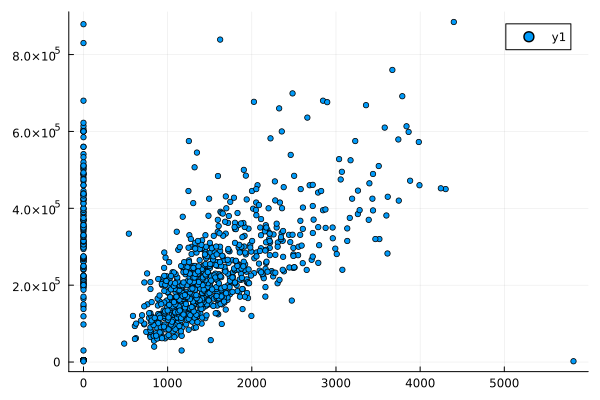

In [3]:
# Построение графика:
using Plots
plot(size=(500,500),leg=false)
x = houses[!,:sq__ft]
y = houses[!,:price]
scatter(x,y,markersize=3)

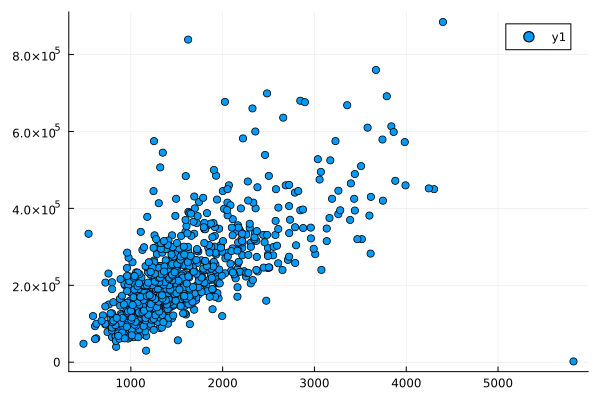

In [4]:
# Фильтрация данных по заданному условию:
filter_houses = houses[houses[!,:sq__ft].>0,:]
# Построение графика:
x = filter_houses[!,:sq__ft]
y = filter_houses[!,:price]
scatter(x,y)

In [5]:
# Фильтрация данных по заданному условию:
filter_houses = houses[houses[!,:sq__ft].>0,:]

Row,street,city,zip,state,beds,baths,sq__ft,type,sale_date,price,latitude,longitude
,String,String15,Int64,String3,Int64,Int64,Int64,String15,String31,Int64,Float64,Float64
1,3526 HIGH ST,SACRAMENTO,95838,CA,2,1,836,Residential,Wed May 21 00:00:00 EDT 2008,59222,38.6319,-121.435
2,51 OMAHA CT,SACRAMENTO,95823,CA,3,1,1167,Residential,Wed May 21 00:00:00 EDT 2008,68212,38.4789,-121.431
3,2796 BRANCH ST,SACRAMENTO,95815,CA,2,1,796,Residential,Wed May 21 00:00:00 EDT 2008,68880,38.6183,-121.444
4,2805 JANETTE WAY,SACRAMENTO,95815,CA,2,1,852,Residential,Wed May 21 00:00:00 EDT 2008,69307,38.6168,-121.439
5,6001 MCMAHON DR,SACRAMENTO,95824,CA,2,1,797,Residential,Wed May 21 00:00:00 EDT 2008,81900,38.5195,-121.436
6,5828 PEPPERMILL CT,SACRAMENTO,95841,CA,3,1,1122,Condo,Wed May 21 00:00:00 EDT 2008,89921,38.6626,-121.328
7,6048 OGDEN NASH WAY,SACRAMENTO,95842,CA,3,2,1104,Residential,Wed May 21 00:00:00 EDT 2008,90895,38.6817,-121.352
8,2561 19TH AVE,SACRAMENTO,95820,CA,3,1,1177,Residential,Wed May 21 00:00:00 EDT 2008,91002,38.5351,-121.481
9,11150 TRINITY RIVER DR Unit 114,RANCHO CORDOVA,95670,CA,2,2,941,Condo,Wed May 21 00:00:00 EDT 2008,94905,38.6212,-121.271


In [6]:
# Подключение пакета Statistics:
using Statistics
# Определение средней цены для определённого типа домов:
by(filter_houses,:type,filter_houses->mean(filter_houses[!,:price]))

LoadError: UndefVarError: `by` not defined in `Main`
Suggestion: check for spelling errors or missing imports.

In [7]:
import Pkg
Pkg.add("Clustering")
using Clustering
# Добавление данных :latitude и :longitude в новый фрейм:
x = filter_houses[[:latitude,:longitude]]
# Конвертация данных в матричный вид:
x = convert(Matrix{Float64}, x)
x = x'

   Resolving package versions...
     Project No packages added to or removed from `C:\Users\eldar\.julia\environments\v1.12\Project.toml`
    Manifest No packages added to or removed from `C:\Users\eldar\.julia\environments\v1.12\Manifest.toml`
Precompiling packages...
   4962.5 ms  ? StochasticDiffEq
   7086.8 ms  ? DifferentialEquations


LoadError: MethodError: no method matching getindex(::DataFrame, ::Vector{Symbol})
The function `getindex` exists, but no method is defined for this combination of argument types.

[0mClosest candidates are:
[0m  getindex(::DataFrame, ::AbstractVector, [91m::Union{AbstractString, Signed, Symbol, Unsigned}[39m)
[0m[90m   @[39m [35mDataFrames[39m [90mC:\Users\eldar\.julia\packages\DataFrames\b4w9K\src\dataframe\[39m[90m[4mdataframe.jl:530[24m[39m
[0m  getindex(::DataFrame, ::AbstractVector{T}, [91m::Colon[39m) where T
[0m[90m   @[39m [35mDataFrames[39m [90mC:\Users\eldar\.julia\packages\DataFrames\b4w9K\src\dataframe\[39m[90m[4mdataframe.jl:605[24m[39m
[0m  getindex(::DataFrame, ::AbstractVector{T}, [91m::Union{Colon, Regex, All, Between, Cols, InvertedIndex, AbstractVector}[39m) where T
[0m[90m   @[39m [35mDataFrames[39m [90mC:\Users\eldar\.julia\packages\DataFrames\b4w9K\src\dataframe\[39m[90m[4mdataframe.jl:579[24m[39m
[0m  ...


In [28]:
k = length(unique(filter_houses[!,:zip]))

66

In [29]:
# Определение k-среднего:
C = kmeans(X,k)

LoadError: UndefVarError: `X` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.

In [30]:
df = DataFrame(cluster = C.assignments,city = filter_houses[!,:city],
latitude = filter_houses[!,:latitude],longitude = filter_houses[!,:longitude],zip = filter_houses[!,:zip])

LoadError: UndefVarError: `C` not defined in `Main`
Suggestion: add an appropriate import or assignment. This global was declared but not assigned.